In [1]:
from __future__ import print_function, unicode_literals, absolute_import, division
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

from tifffile import imread
from csbdeep.utils import Path, download_and_extract_zip_file, plot_some
from csbdeep.io import save_tiff_imagej_compatible
from csbdeep.models import CARE
import h5py
import os
from lazy5.inspect import get_attrs_dset
import numpy as np
import matplotlib.pyplot as plt
from utils.datagen import create_spend_patches, norm_percentiles,create_spend_dataset_enhanced
from csbdeep.utils import plot_some

2026-03-02 23:03:33.545211: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [57]:
DATA_FOLDER = "/storage/home/hcoda1/9/hxu419/scratch/n2n_data/20260213"
filename = "preprocessed_nofilter_myo3_day11_202602131225"
f = h5py.File(os.path.join(DATA_FOLDER,filename + ".h5"), 'r')
# Access the group
preprocessed_group = f['preprocessed_images']

# Print the names of items within the group
print("Items within the 'preprocessed_images' group:")
for key in preprocessed_group.keys():
    print(key)
# Access the 'medfilter_ratio' dataset within the 'preprocessed_images' group
raw_ratio = f['preprocessed_images/nofilter_ratio']

# Print the shape of the extracted dataset
print("Shape of 'nofilter_ratio' dataset:", raw_ratio.shape)
attrs = get_attrs_dset(f, 'preprocessed_images/nofilter_ratio')

Items within the 'preprocessed_images' group:
nofilter_dark
nofilter_nrb_for_ratio
nofilter_ratio
Shape of 'nofilter_ratio' dataset: (460, 500, 2304)


In [58]:
#Get the wavenumber axis from the attributes
coeffs = attrs['Calib.a_vec']
attrs['Calib.n_pix']= 2304
n_pix = 2304
ctr = attrs['Calib.ctr_wl0']
probe = attrs['Calib.probe']
probe *= 1e-7
converted_nm = np.polyval(coeffs, np.arange(n_pix))
converted_nm *= 0.0000001
wn = 1/converted_nm - 1/probe


In [59]:

# Select wn values between 400 and 1800
fast_axis_start = 0
slow_axis_start = 0
ratio = raw_ratio[slow_axis_start:,:,:] # cut off where the stage is not moving
fast_axis_end = fast_axis_start + ratio.shape[1]
wn_mask = (wn >= 400) & (wn <= 3400)
wn_selected = wn[wn_mask]
indices = np.where(wn_mask)[0]
ratio_selected = ratio[:, fast_axis_start:fast_axis_end, indices]
signature_index = 310
point_signal = [90, 70]  # Example point (y, x)
point_noise = [50,25]  # Example point (y, x)s

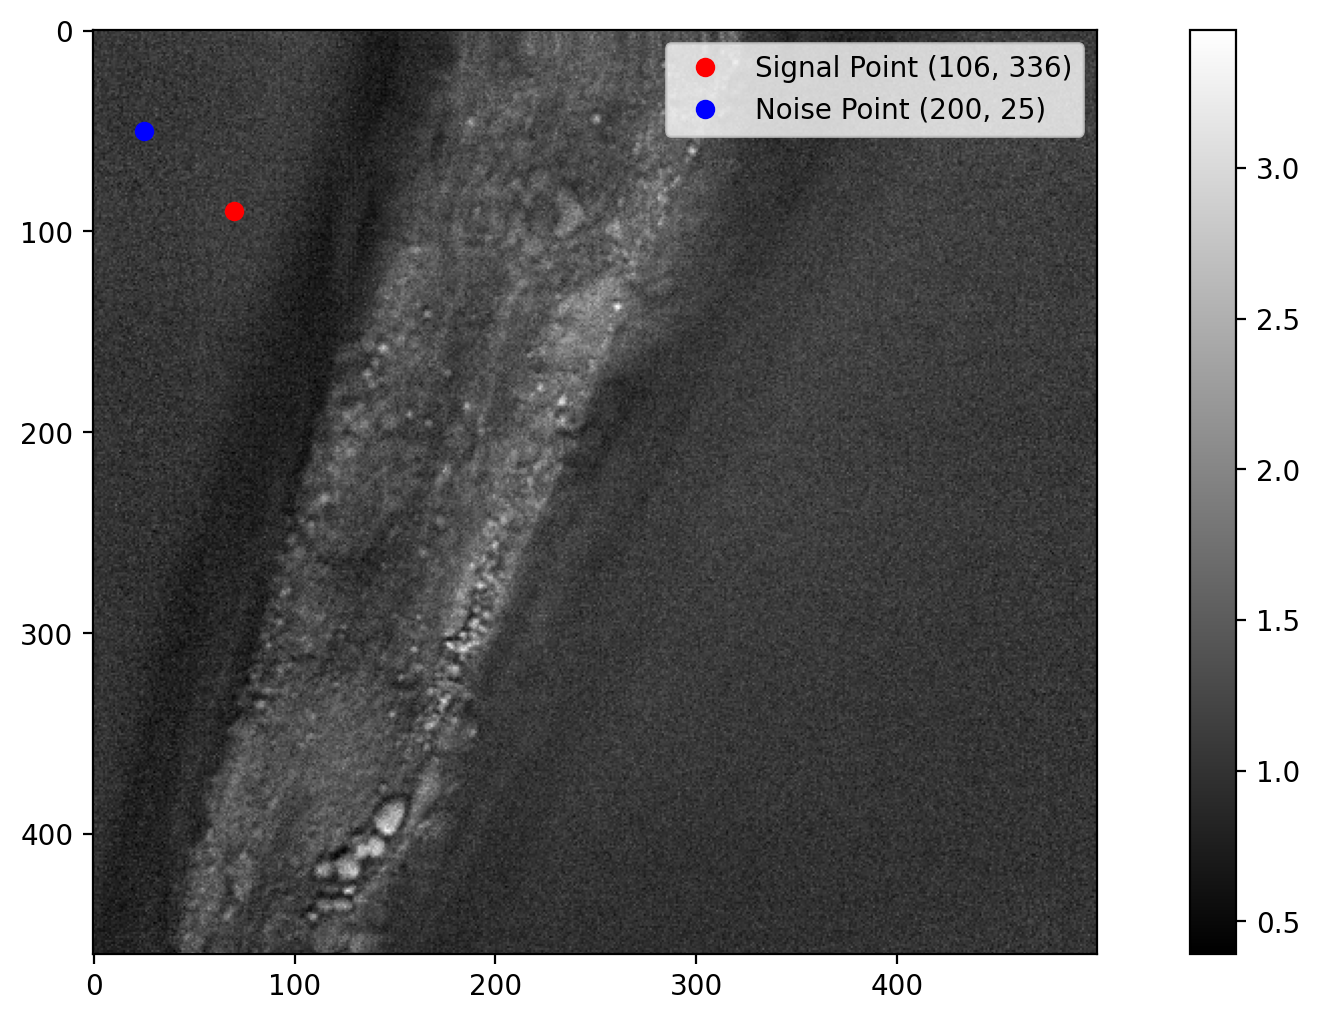

Text(0.5, 1.0, 'Spectra at Selected Points')

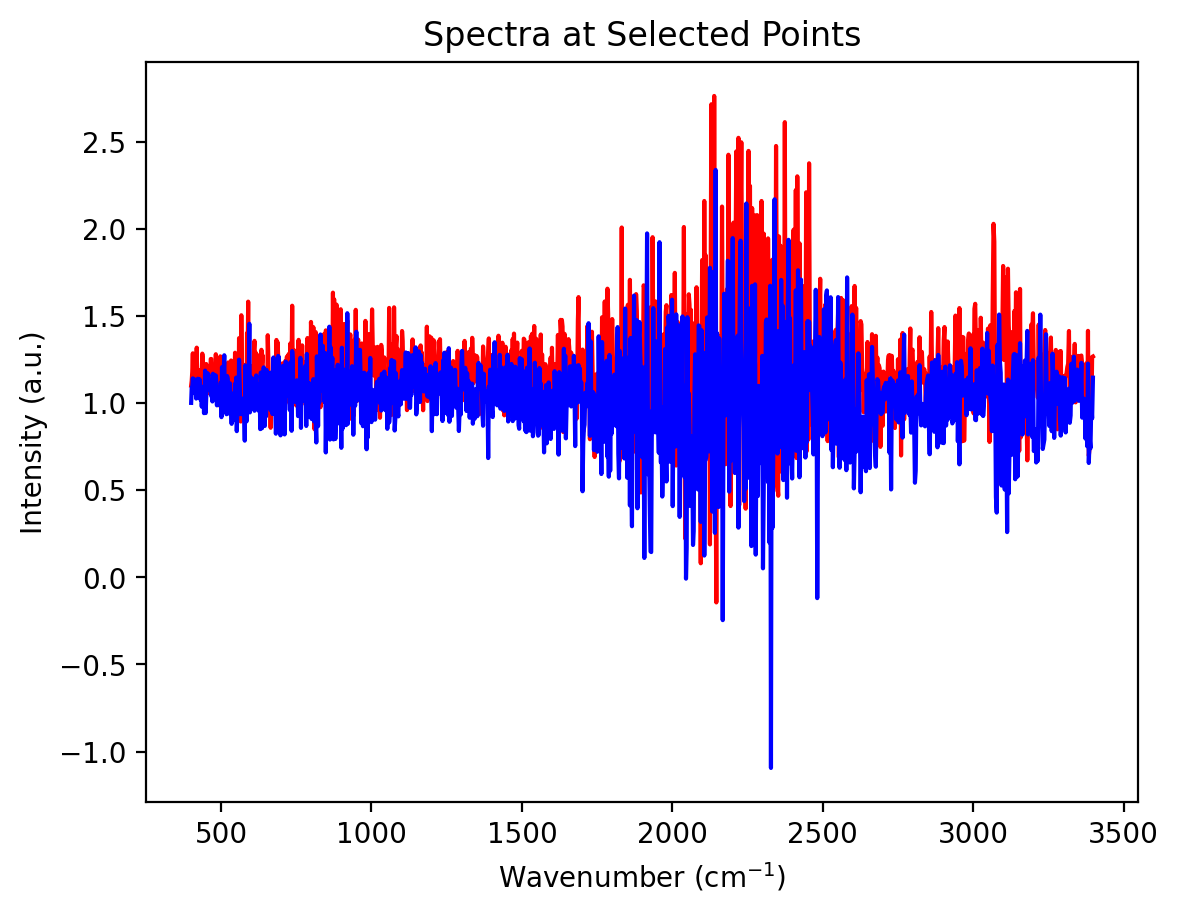

In [60]:
plt.figure(figsize=(12, 6))
plt.imshow(ratio_selected[:,:,signature_index], cmap='gray')
plt.plot(point_signal[1], point_signal[0], 'ro', label='Signal Point (106, 336)')
plt.plot(point_noise[1], point_noise[0], 'bo', label='Noise Point (200, 25)')
plt.legend()
plt.colorbar()
plt.show()

plt.figure()
plt.plot(wn_selected, ratio_selected[point_signal[0], point_signal[1], :],color="r", label='Signal Point (106, 336)')
plt.plot(wn_selected, ratio_selected[point_noise[0], point_noise[1], :], color="b", label='Noise Point (200, 25)')
plt.xlabel('Wavenumber (cm$^{-1}$)')
plt.ylabel('Intensity (a.u.)')
plt.title('Spectra at Selected Points')

In [61]:
print(ratio_selected.shape)
x = ratio_selected.transpose(2,0,1)
axes = 'ZYX'
print(x.shape, axes)

(460, 500, 1326)
(1326, 460, 500) ZYX


In [62]:
model = CARE(config=None, name='wpermute_model_4layers_20260302', basedir='/storage/home/hcoda1/9/hxu419/scratch/models')

Loading network weights from 'weights_best.h5'.


In [63]:
restored = model.predict(x, axes, n_tiles=(16,4,4))

100%|██████████| 240/240 [01:30<00:00,  2.65it/s]  


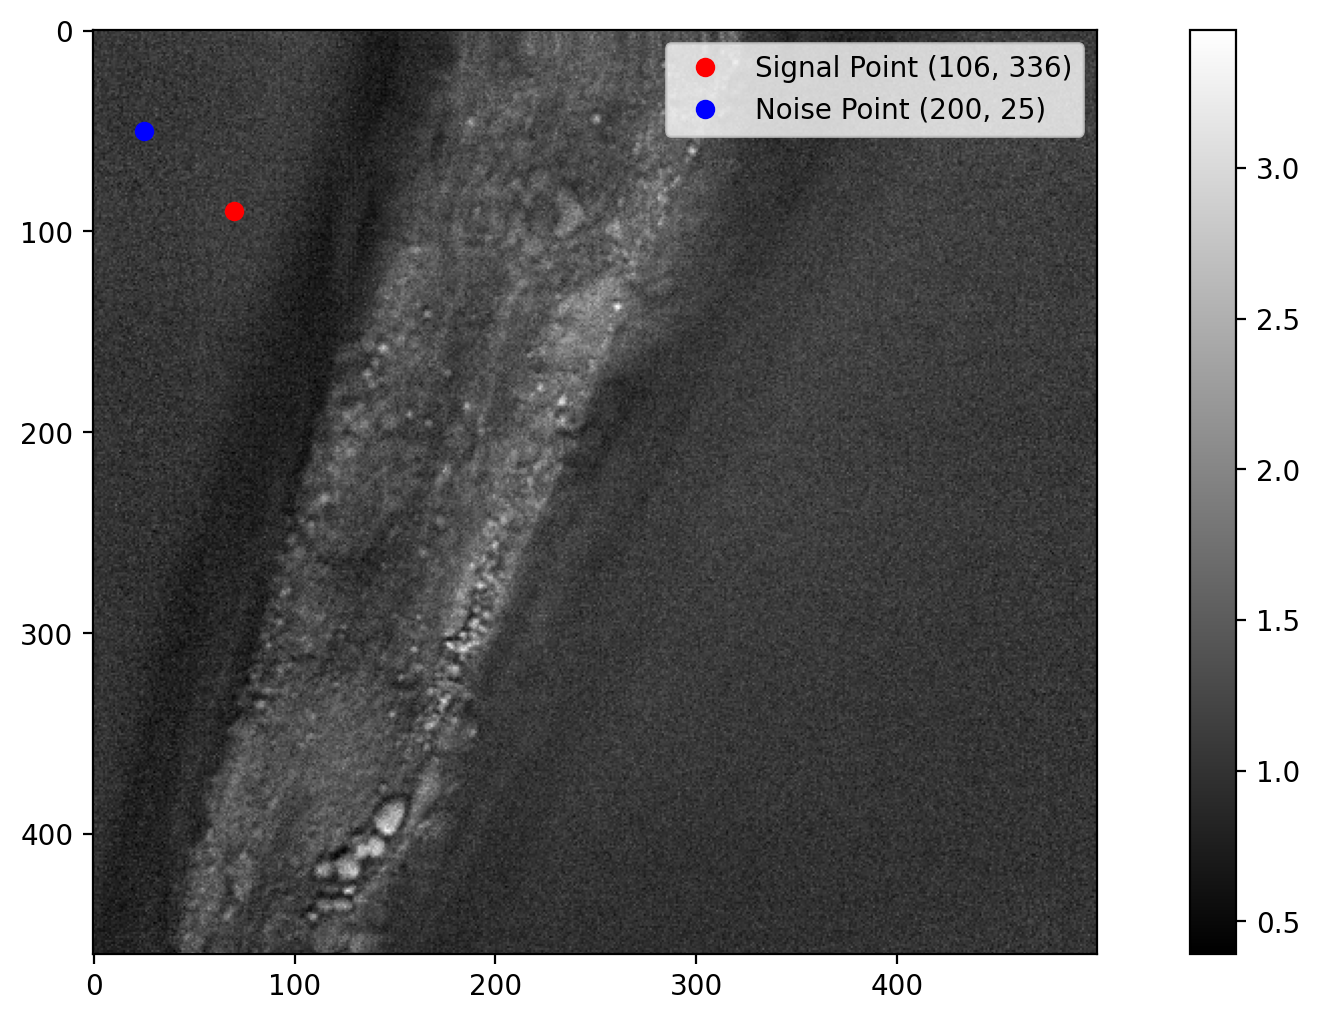

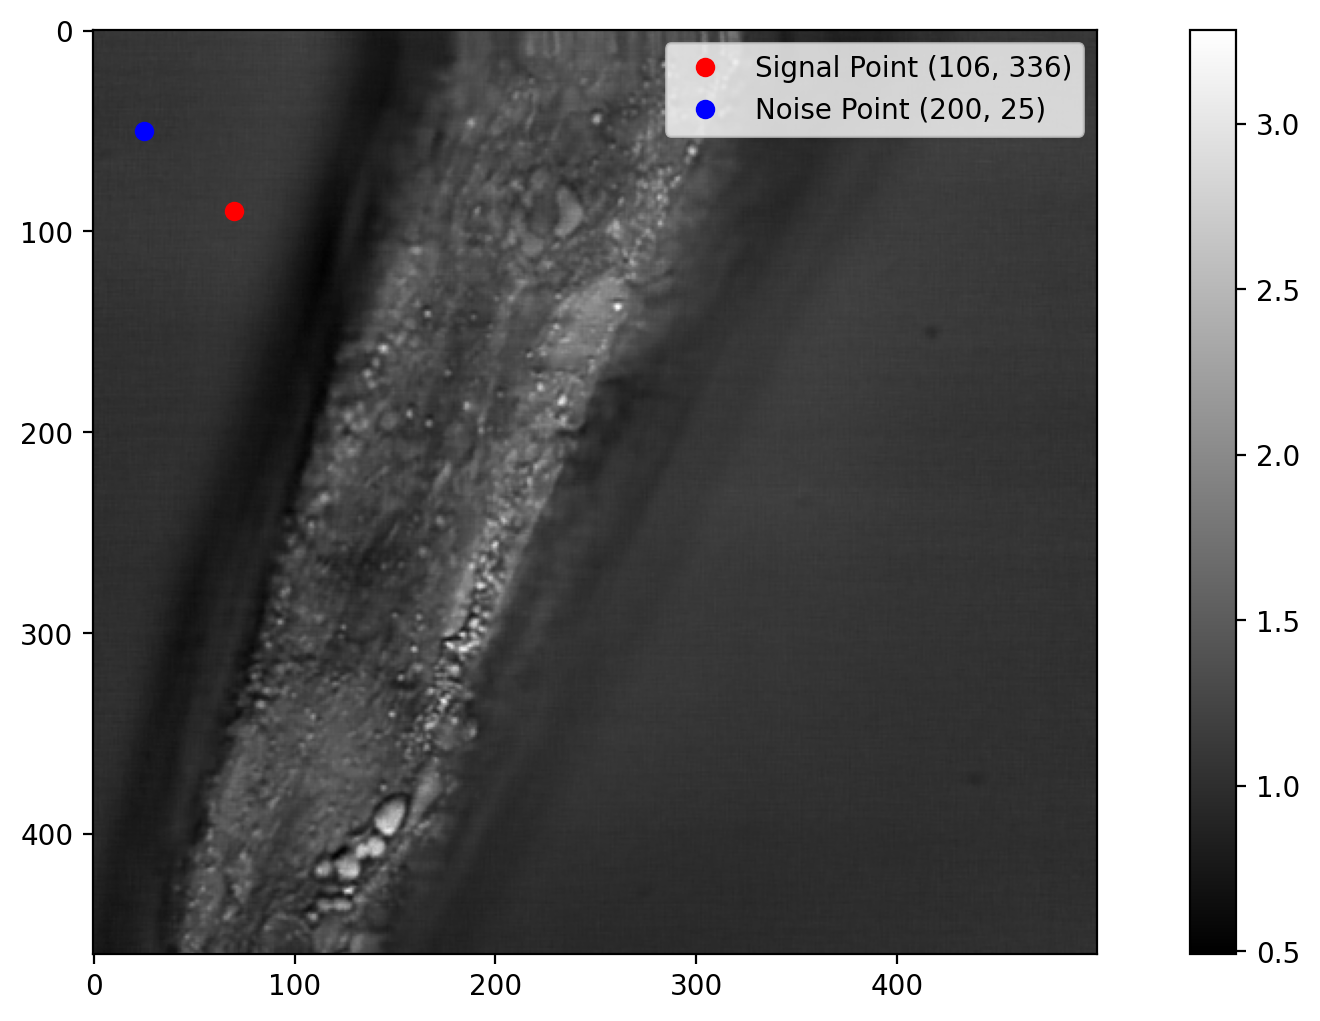

Text(0.5, 1.0, 'Spectra at Selected Points')

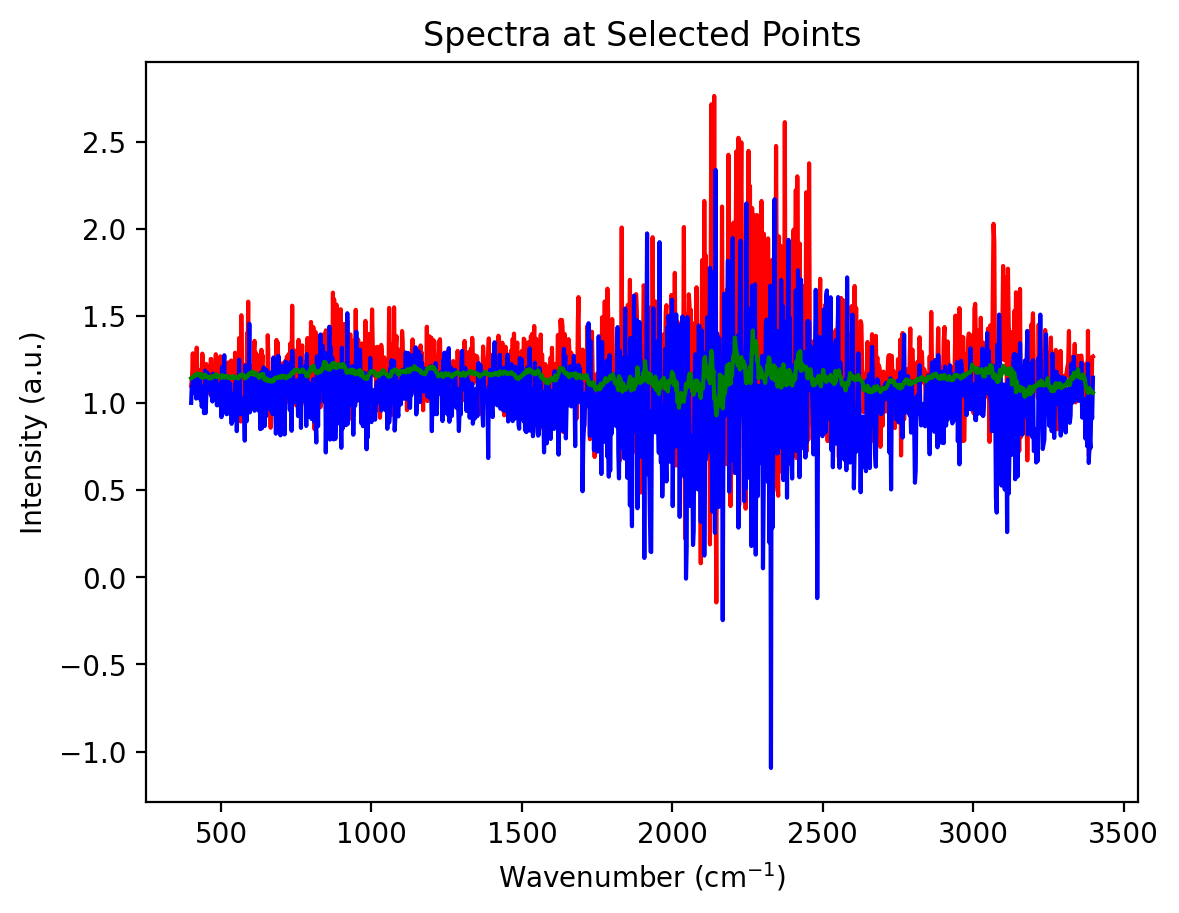

In [64]:
plt.figure(figsize=(12, 6))
plt.imshow(ratio_selected[:,:,signature_index], cmap='gray')
plt.plot(point_signal[1], point_signal[0], 'ro', label='Signal Point (106, 336)')
plt.plot(point_noise[1], point_noise[0], 'bo', label='Noise Point (200, 25)')
plt.legend()
plt.colorbar()
plt.show()

plt.figure(figsize=(12, 6))
plt.imshow(restored[signature_index,:,:,], cmap='gray')
plt.plot(point_signal[1], point_signal[0], 'ro', label='Signal Point (106, 336)')
plt.plot(point_noise[1], point_noise[0], 'bo', label='Noise Point (200, 25)')
plt.legend()
plt.colorbar()
plt.show()



plt.figure()
plt.plot(wn_selected, ratio_selected[point_signal[0], point_signal[1], :],color="r", label='Signal Point (106, 336)')
plt.plot(wn_selected, ratio_selected[point_noise[0], point_noise[1], :], color="b", label='Noise Point (100, 25)')
plt.plot(wn_selected, restored[:, point_signal[0], point_signal[1]], 'g', label='Restored Signal Point (106, 336)')
plt.xlabel('Wavenumber (cm$^{-1}$)')
plt.ylabel('Intensity (a.u.)')
plt.title('Spectra at Selected Points')



In [65]:
np.savez(os.path.join(DATA_FOLDER,"denoised_"+ filename + ".npz"), raw=ratio_selected, denoised=restored, wn=wn_selected)